In [2]:
from datasets import load_dataset
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import regex as re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

/home/chiraagkv/miniconda3/envs/StatML/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Downloading the dataset

In [3]:
dataset = load_dataset("imdb")

# Data Representation

## A. Sparse Features

- Includes BoW and TF-IDF feature extraction
- We have included our own implementation of certain key functions to show clarity in concepts being used. 

### From-the-scratch Implementation

In [31]:
def clean_html(text):
    return re.sub(r'<.*?>', ' ', text)

def tokenize(text, mode='unigram'):
    text = text.lower()
    text = clean_html(text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and t]

    if mode == 'unigram':
        return tokens

    elif mode == 'bigram':
        bigrams = [tokens[i] + "_" + tokens[i+1] for i in range(len(tokens)-1)]
        return bigrams

    elif mode == 'both':
        bigrams = [tokens[i] + "_" + tokens[i+1] for i in range(len(tokens)-1)]
        return tokens + bigrams
    else:
       raise ValueError("mode is not in {'unigram', 'bigram', 'both'}")


def bowdict(docs, mode='unigram'):
  d = {}
  x = 0
  for i in docs:
    i = tokenize(i, mode)
    for j in i:
      if j not in d:
        d[j] = x
        x+= 1
  return d

def bow_vectorize(doc, vocab, mode='unigram'):
    vec = np.zeros(len(vocab))
    for word in tokenize(doc, mode):
        if word in vocab:
          vec[vocab[word]] += 1

    return vec

def bow_matrix(docs, mode='unigram'):
    vocab = bowdict(docs, mode)
    matrix = np.array([bow_vectorize(doc, vocab, mode) for doc in docs])
    return matrix, vocab

In [32]:
def prune_vocab(bowed, vocab, min_df=5, max_df_ratio=0.8):
    N = bowed.shape[0]
    df = (bowed > 0).sum(axis=0)

    keep = (df >= min_df) & (df <= max_df_ratio * N)

    new_vocab = {}
    new_id = 0

    for word, idx in vocab.items():
        if keep[idx]:
            new_vocab[word] = new_id
            new_id += 1

    return new_vocab, keep

def apply_pruning(bowed, keep_mask):
    return bowed[:, keep_mask]

In [33]:
def tf(bowed):
    row_sums = bowed.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return bowed / row_sums

def idf(bowed):
    N = bowed.shape[0]
    df = (bowed > 0).sum(axis=0)
    return np.log((N + 1) / (df + 1)) + 1


def build_index(docs, mode='unigram', min_df=5, max_df_ratio=0.8):
    bowed_full, vocab_full = bow_matrix(docs, mode)
    vocab, keep_mask = prune_vocab(bowed_full, vocab_full, min_df, max_df_ratio)

    bowed = apply_pruning(bowed_full, keep_mask)

    tf_bowed = tf(bowed)
    idf_vec = idf(bowed)

    tfidf_docs = tf_bowed * idf_vec

    norms = np.linalg.norm(tfidf_docs, axis=1, keepdims=True)
    norms[norms == 0] = 1
    tfidf_docs = tfidf_docs / norms

    return tfidf_docs, vocab, idf_vec

In [34]:
def vectorize_query(query, vocab, idf_vec, mode='unigram'):
    vec = np.zeros(len(vocab))
    for word in tokenize(query, mode):
        if word in vocab:
            vec[vocab[word]] += 1

    if vec.sum() == 0:
        return vec
    tf_vec = vec / vec.sum()
    res = tf_vec * idf_vec
    norm = np.linalg.norm(res)
    if norm:
        res = res / norm
    return res

### EDA

In [35]:
train = dataset["train"]
test = dataset["test"]

X_train_docs = train["text"]
y_train = np.array(train["label"])

X_test_docs = test["text"]
y_test = np.array(test["label"])

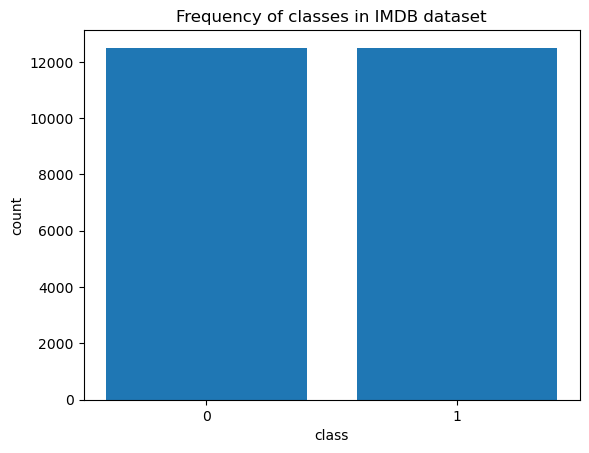

In [36]:
classes, counts = np.unique(y_train,return_counts=True)
plt.bar(classes, counts)
plt.xlabel('class')
plt.ylabel('count')

plt.xticks(classes)

plt.title('Frequency of classes in IMDB dataset')
plt.show()

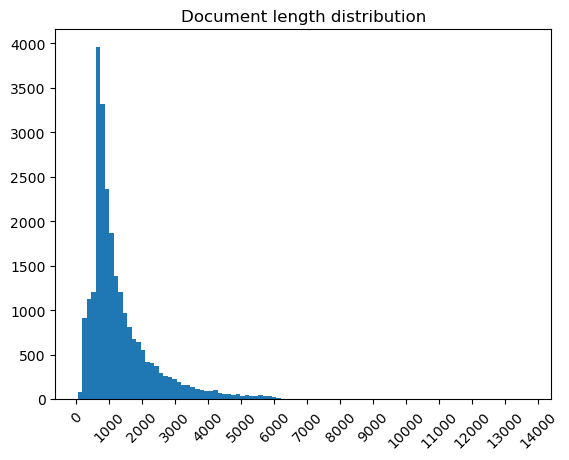

In [37]:
document_lengths = [len(i) for i in X_train_docs]

plt.hist(document_lengths, bins=100)
plt.xticks(np.arange(0, 15000, 1000), rotation=45)
plt.title("Document length distribution")
plt.show()


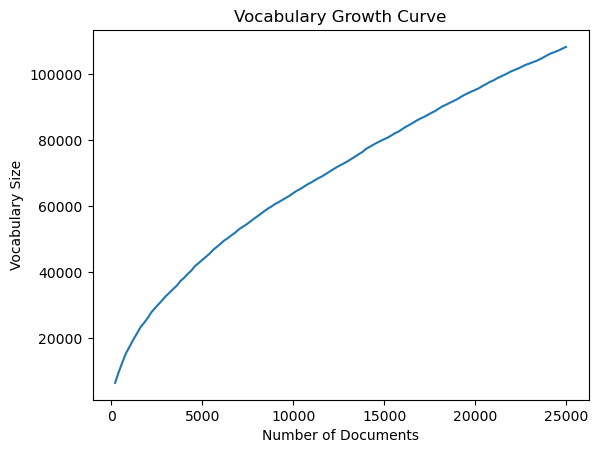

In [38]:
vocab = set()
vocab_sizes = []
num_docs = []

step = 200

for i, doc in enumerate(X_train_docs):
    tokens = tokenize(doc, mode='unigram')
    vocab.update(tokens)

    if (i + 1) % step == 0:
        num_docs.append(i + 1)
        vocab_sizes.append(len(vocab))
plt.plot(num_docs, vocab_sizes)
plt.xlabel("Number of Documents")
plt.ylabel("Vocabulary Size")
plt.title("Vocabulary Growth Curve")
plt.show()

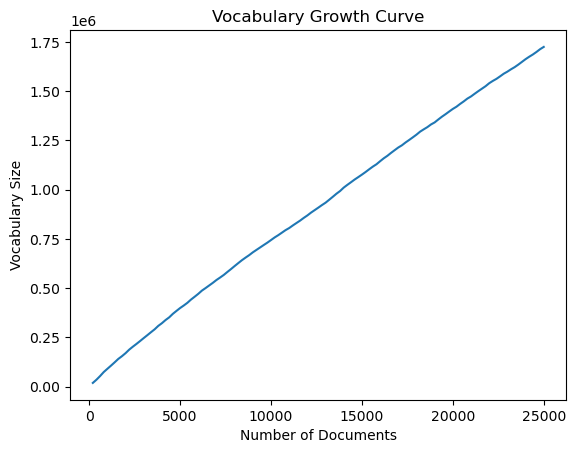

In [39]:
vocab = set()
vocab_sizes = []
num_docs = []

step = 200

for i, doc in enumerate(X_train_docs):
    tokens = tokenize(doc, mode='bigram')
    vocab.update(tokens)

    if (i + 1) % step == 0:
        num_docs.append(i + 1)
        vocab_sizes.append(len(vocab))
plt.plot(num_docs, vocab_sizes)
plt.xlabel("Number of Documents")
plt.ylabel("Vocabulary Size")
plt.title("Vocabulary Growth Curve")
plt.show()

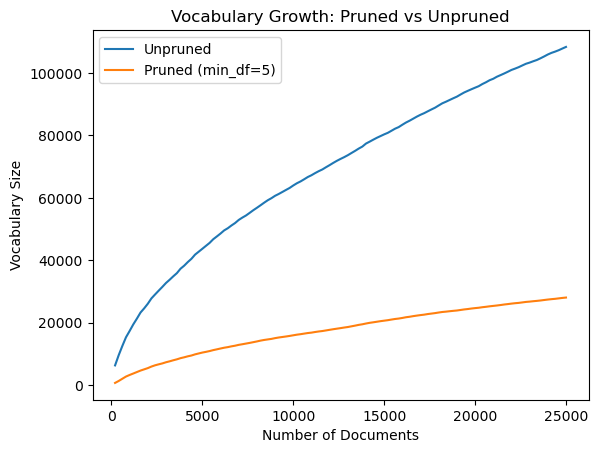

In [40]:
tokenized_docs = [tokenize(doc, mode='unigram') for doc in X_train_docs]

from collections import defaultdict

vocab = set()
df_counts = defaultdict(int)

vocab_sizes = []
pruned_sizes = []
num_docs = []

step = 200
min_df = 5

for i, tokens in enumerate(tokenized_docs):
    unique_tokens = set(tokens)

    vocab.update(unique_tokens)

    for t in unique_tokens:
        df_counts[t] += 1

    if (i + 1) % step == 0:
        num_docs.append(i + 1)

        vocab_sizes.append(len(vocab))


        pruned_vocab = [t for t in vocab if df_counts[t] >= min_df]
        pruned_sizes.append(len(pruned_vocab))

plt.plot(num_docs, vocab_sizes, label="Unpruned")
plt.plot(num_docs, pruned_sizes, label=f"Pruned (min_df={min_df})")

plt.xlabel("Number of Documents")
plt.ylabel("Vocabulary Size")
plt.title("Vocabulary Growth: Pruned vs Unpruned")
plt.legend()
plt.show()        

#### Finding Positive and Negative Words

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    preprocessor=lambda x: re.sub(r'<.*?>', ' ', x.lower()),
    lowercase=True,
    stop_words='english',
    ngram_range=(1,1),
    min_df=5,
    max_df=0.8,
    norm='l2'
)

X_tfidf = vectorizer.fit_transform(X_train_docs)


X_pos = X_tfidf[y_train == 1]
X_neg = X_tfidf[y_train == 0]

mean_pos = np.asarray(X_pos.mean(axis=0)).ravel()
mean_neg = np.asarray(X_neg.mean(axis=0)).ravel()

feature_names = np.array(vectorizer.get_feature_names_out())

top_k = 20

top_pos_idx = np.argsort(mean_pos)[-top_k:][::-1]
top_pos_words = feature_names[top_pos_idx]
top_pos_scores = mean_pos[top_pos_idx]

top_neg_idx = np.argsort(mean_neg)[-top_k:][::-1]
top_neg_words = feature_names[top_neg_idx]
top_neg_scores = mean_neg[top_neg_idx]

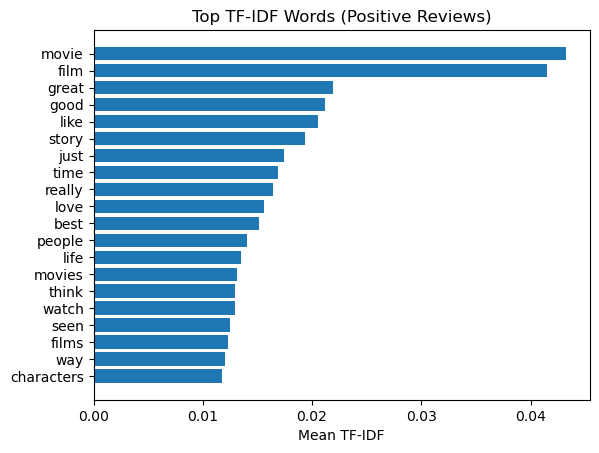

In [47]:
plt.figure()
plt.barh(top_pos_words[::-1], top_pos_scores[::-1])
plt.title("Top TF-IDF Words (Positive Reviews)")
plt.xlabel("Mean TF-IDF")
plt.show()

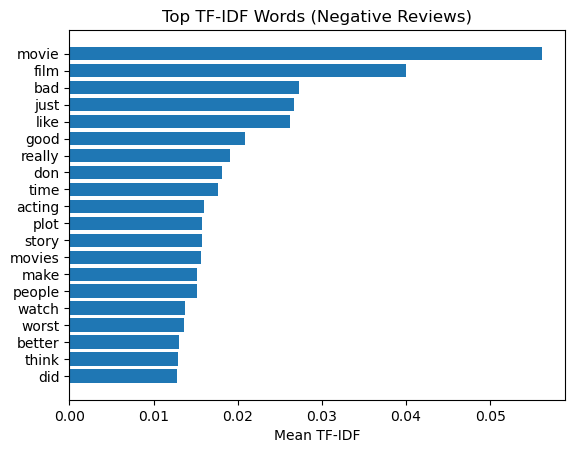

In [48]:
plt.figure()
plt.barh(top_neg_words[::-1], top_neg_scores[::-1])
plt.title("Top TF-IDF Words (Negative Reviews)")
plt.xlabel("Mean TF-IDF")
plt.show()